In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
deep = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/sv1_cumulative_lrg.fits'))
# deep = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/sv1_cumulative_lrg.fits'))
deep['EFFTIME_ELG'] = 8.60 * deep['TSNR2_ELG']
deep['EFFTIME_LRG'] = 12.15 * deep['TSNR2_LRG']
deep['zfibermag'] = 22.5 - 2.5*np.log10(deep['FIBERFLUX_Z']) - 1.211 * deep['EBV']

# Remove FIBERSTATUS!=0 fibers
mask = deep['COADD_FIBERSTATUS']==0
print('COADD_FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

mask = deep['ZWARN']==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Apply LRG mask
mask = deep['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Remove QSO targets
mask = deep['SV1_DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Remove duplidates keeping the higher EFFTIME objects
deep.sort('EFFTIME_LRG', reverse=True)
_, idx_keep = np.unique(deep['TARGETID'], return_index=True)
deep = deep[idx_keep]
print(len(deep), len(np.unique(deep['TARGETID'])))

deep = deep.copy()
# Redshift quality: custom DELTACHI2 vs z cut
d = (10**(3 - 3.5*deep['Z']))
deep['q_deep'] = ((deep['DELTACHI2']>d) & (deep['DELTACHI2']>10)) | (deep['DELTACHI2']>30)
deep['q_deep'] &= deep['Z']<1.4
deep['q_deep'] &= deep['ZWARN']<1.4

# Require a minimum depth
min_depth = 3000.
mask = deep['EFFTIME_LRG']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
deep = deep[mask]

COADD_FIBERSTATUS 46319 8916 0.16141938987960533
No data 45437 882 0.01904186187093849
LRG mask 41340 4097 0.09016880515879129
Remove QSO targets 39668 1672 0.040445089501693274
39533 39533
Min depth 30377 9156 0.768396023575241


In [4]:
nominal = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/sv1_1x_depth_lrg.fits'))
# nominal = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/sv1_1x_depth_lrg.fits'))
nominal['EFFTIME_ELG'] = 8.60 * nominal['TSNR2_ELG']
nominal['EFFTIME_LRG'] = 12.15 * nominal['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = nominal['COADD_FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
nominal = nominal[mask]

# Remove "no data" fibers
mask = nominal['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
nominal = nominal[mask]

# Apply LRG mask
mask = nominal['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
nominal = nominal[mask]

# Remove QSO targets
mask = nominal['SV1_DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
nominal = nominal[mask]

# Require a minimum depth
min_depth = 800.
mask = nominal['EFFTIME_LRG']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
nominal = nominal[mask]

# Redshift quality: custom DELTACHI2 vs z cut
d = (10**(3 - 3.5*nominal['Z']))
nominal['q'] = ((nominal['DELTACHI2']>d) & (nominal['DELTACHI2']>10)) | (nominal['DELTACHI2']>30)
nominal['q'] &= nominal['Z']<1.4
nominal['q'] &= nominal['ZWARN']<1.4

mask = nominal['main_lrg'].copy()
print('Main LRGs', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
nominal = nominal[mask]

FIBERSTATUS 27110 4943 0.15421333416528873
No data 27110 0 0.0
LRG mask 25008 2102 0.07753596458871265
Remove QSO targets 24493 515 0.020593410108765194
Min depth 22883 1610 0.9342669334095456
Main LRGs 6191 16692 0.27055019009745224


In [5]:
lowsp = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/sv1_lowspeed_lrg.fits'))
# lowsp = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/sv1_lowspeed_lrg.fits'))
lowsp['EFFTIME_ELG'] = 8.60 * lowsp['TSNR2_ELG']
lowsp['EFFTIME_LRG'] = 12.15 * lowsp['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = lowsp['COADD_FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
lowsp = lowsp[mask]

# Remove "no data" fibers
mask = lowsp['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
lowsp = lowsp[mask]

# Apply LRG mask
mask = lowsp['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
lowsp = lowsp[mask]

# Remove QSO targets
mask = lowsp['SV1_DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
lowsp = lowsp[mask]

# Require a minimum depth
min_depth = 800.
mask = lowsp['EFFTIME_LRG']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
lowsp = lowsp[mask]

# Redshift quality: custom DELTACHI2 vs z cut
d = (10**(3 - 3.5*lowsp['Z']))
lowsp['q'] = ((lowsp['DELTACHI2']>d) & (lowsp['DELTACHI2']>10)) | (lowsp['DELTACHI2']>30)
lowsp['q'] &= lowsp['Z']<1.4
lowsp['q'] &= lowsp['ZWARN']<1.4

mask = lowsp['main_lrg'].copy()
print('Main LRGs', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
lowsp = lowsp[mask]

FIBERSTATUS 5004 909 0.1537290715372907
No data 5004 0 0.0
LRG mask 4773 231 0.046163069544364506
Remove QSO targets 4675 98 0.020532160067043788
Min depth 4403 272 0.9418181818181818
Main LRGs 1159 3244 0.26322961617079266


In [6]:
deep_columns_old = ['TARGETID', 'Z', 'ZERR', 'ZWARN', 'SPECTYPE', 'DELTACHI2', 'EFFTIME_LRG', 'EFFTIME_ELG']
deep_columns_new = ['TARGETID', 'Z_deep', 'ZERR_deep', 'ZWARN_deep', 'SPECTYPE_deep', 'DELTACHI2_deep', 'EFFTIME_LRG_deep', 'EFFTIME_ELG_deep']
deep1 = deep.copy()
deep1.rename_columns(deep_columns_old, deep_columns_new)

nominal = join(nominal, deep1[deep_columns_new], keys='TARGETID')
lowsp = join(lowsp, deep1[deep_columns_new], keys='TARGETID')

In [7]:
tileids = np.intersect1d(nominal['TILEID'], lowsp['TILEID'])
mask = np.in1d(nominal['TILEID'], tileids)
nominal = nominal[mask]
mask = np.in1d(lowsp['TILEID'], tileids)
lowsp = lowsp[mask]

In [8]:
nominal['weight'] = 1.
lowsp['weight'] = 1.

for tile in tileids:
    mask = nominal['TILEID']==tile
    if nominal['subset'][mask].max()>1:
        nominal['weight'][mask]/=nominal['subset'].max()
    mask = lowsp['TILEID']==tile
    if lowsp['subset'][mask].max()>1:
        lowsp['weight'][mask]/=lowsp['subset'].max()
        
print(np.sum(nominal['weight']))
print(np.sum(lowsp['weight']))

710.1666666666665
784.5


In [9]:
# Rejection rates
print(len(nominal), np.sum(~nominal['q']), np.sum(~nominal['q'])/len(nominal))
print(len(lowsp), np.sum(~lowsp['q']), np.sum(~lowsp['q'])/len(lowsp))

4261 56 0.013142454822811546
1158 21 0.018134715025906734


In [10]:
# Weighted rejection rates
print(np.sum(~nominal['q']*nominal['weight'])/np.sum(nominal['weight']))
print(np.sum(~lowsp['q']*lowsp['weight'])/np.sum(lowsp['weight']))

0.013142454822811548
0.0165710643722116


In [11]:
0.0165710643722116/0.013142454822811548

1.2608804516070289

In [12]:
zdiff_threshold = 0.0033
nominal['fail'] = np.abs((nominal['Z'] - nominal['Z_deep'])/(1 + nominal['Z_deep'])) > zdiff_threshold
lowsp['fail'] = np.abs((lowsp['Z'] - lowsp['Z_deep'])/(1 + lowsp['Z_deep'])) > zdiff_threshold

In [13]:
# Catastrophic failure rates
print(len(nominal), np.sum(nominal['fail']), np.sum(nominal['fail'])/len(nominal))
print(len(lowsp), np.sum(lowsp['fail']), np.sum(lowsp['fail'])/len(lowsp))

4261 49 0.011499647969960104
1158 20 0.017271157167530225


In [14]:
# Weighted catastrophic failure rates
print(np.sum(nominal['fail']*nominal['weight'])/np.sum(nominal['weight']))
print(np.sum(lowsp['fail']*lowsp['weight'])/np.sum(lowsp['weight']))

0.011499647969960102
0.014659018483110261


In [15]:
0.014659018483110261/0.011499647969960102

1.274736280745568

In [16]:
# Catastrophic failure rates of "good" redshifts
mask = nominal['q'] & nominal['fail']
print(len(nominal), np.sum(mask), np.sum(mask)/np.sum(nominal['q']))
mask = lowsp['q'] & lowsp['fail']
print(len(lowsp), np.sum(mask), np.sum(mask)/np.sum(lowsp['q']))

4261 17 0.004042806183115339
1158 8 0.007036059806508356


In [17]:
# Weighted catastrophic failure rates of "good" redshifts
mask = nominal['q'] & nominal['fail']
print(np.sum(mask*nominal['weight'])/np.sum(nominal['q']*nominal['weight']))
mask = lowsp['q'] & lowsp['fail']
print(np.sum(mask*lowsp['weight'])/np.sum(lowsp['q']*lowsp['weight']))

0.004042806183115339
0.005832793259883344


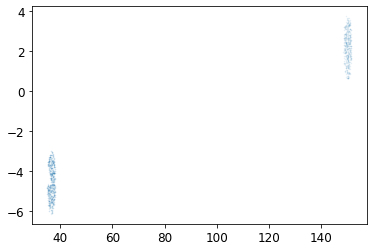

In [18]:
plt.plot(lowsp['TARGET_RA'], lowsp['TARGET_DEC'], '.', ms=1, alpha=0.1)

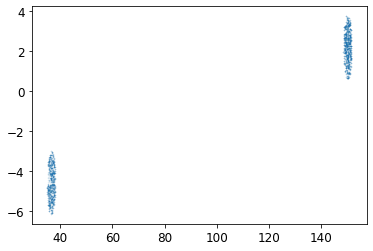

In [19]:
plt.plot(nominal['TARGET_RA'], nominal['TARGET_DEC'], '.', ms=1, alpha=0.1)

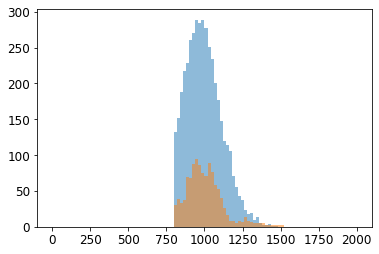

In [20]:
plt.hist(nominal['EFFTIME_LRG'], 100, range=(0, 2000), alpha=0.5)
plt.hist(lowsp['EFFTIME_LRG'], 100, range=(0, 2000), alpha=0.5)
plt.show()

In [21]:
nominal['speed'] = nominal['EFFTIME_LRG']*10**(2*2.165*nominal['EBV']/2.5)/nominal['COADD_EXPTIME']
lowsp['speed'] = lowsp['EFFTIME_LRG']*10**(2*2.165*lowsp['EBV']/2.5)/lowsp['COADD_EXPTIME']

0.64742965
0.30007488


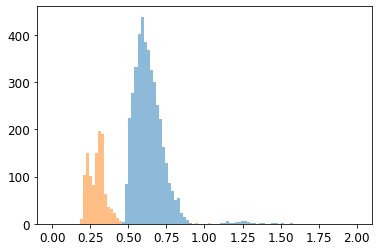

In [22]:
print(np.mean(nominal['speed']))
print(np.mean(lowsp['speed']))
plt.hist(nominal['speed'], 100, range=(0, 2), alpha=0.5)
plt.hist(lowsp['speed'], 100, range=(0, 2), alpha=0.5)
plt.show()